# Тема 3. Деревья решений и метод ближайших соседей

## Практика: первая модель на «Титанике»

До сих пор мы только смотрели на данные — глазами и через таблицы. Сегодня в первый раз **обучаем настоящую модель** и предсказываем ей выживание пассажиров «Титаника».

Самостоятельная работа. В ячейках с `# Ваш код здесь` — напишите код и получите ответ. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

**1. Подготовка данных.** Модели нужны числа, а не текст, и не любят пропуски. Закодируем `Sex` в 0/1 и заполним пропуски в `Age` медианой — код целиком, эта часть не про деревья.

In [4]:
data = pd.read_csv("../../data/titanic_train.csv", index_col="PassengerId")
data["Sex"] = (data["Sex"] == "male").astype(int)
data["Age"] = data["Age"].fillna(data["Age"].median())

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = data[features]
y = data["Survived"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_valid.shape

((623, 6), (268, 6))

**2. Обучите дерево решений с парамтерами max_depth=3 и random_state=RANDOM_STATE на `X_train`/`y_train`. Посчитайте `.score()` на `X_train` и на `X_valid` отдельно.**


In [7]:
first_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
first_tree.fit(X_train, y_train)
first_tree.score(X_train, y_train),first_tree.score(X_valid, y_valid)

(0.8298555377207063, 0.7947761194029851)

**3. Переобучение своими руками.** Для `max_depth` от 1 до 15 обучите дерево и запишите accuracy на train и valid. Постройте график: ось X — глубина, две линии — train и valid accuracy.

Где train и valid расходятся? Это и есть точка, после которой дерево начинает переобучаться.


[0.7761194029850746,
 0.7686567164179104,
 0.7947761194029851,
 0.7985074626865671,
 0.7910447761194029,
 0.7910447761194029,
 0.7985074626865671,
 0.7723880597014925,
 0.7835820895522388,
 0.7835820895522388,
 0.7761194029850746,
 0.7798507462686567,
 0.7761194029850746,
 0.7947761194029851,
 0.7910447761194029]

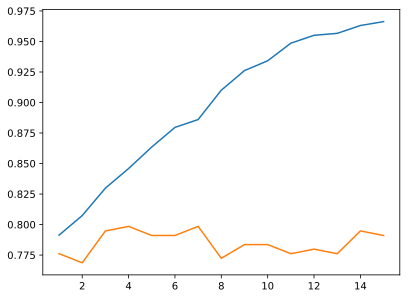

In [19]:
train_acc = []
val_acc = []
for i in range(1,16):
    tree = DecisionTreeClassifier(max_depth=i, random_state=RANDOM_STATE).fit(X_train, y_train)
    train_acc.append(tree.score(X_train, y_train))
    val_acc.append(tree.score(X_valid, y_valid))

plt.plot(range(1,16),train_acc,range(1,16),val_acc)

**4. Возьмите глубину, которая дала лучший `valid`-результат на предыдущем графике, обучите дерево с ней и визуализируйте через `plot_tree` (укажите `feature_names=features`, `filled=True`).**


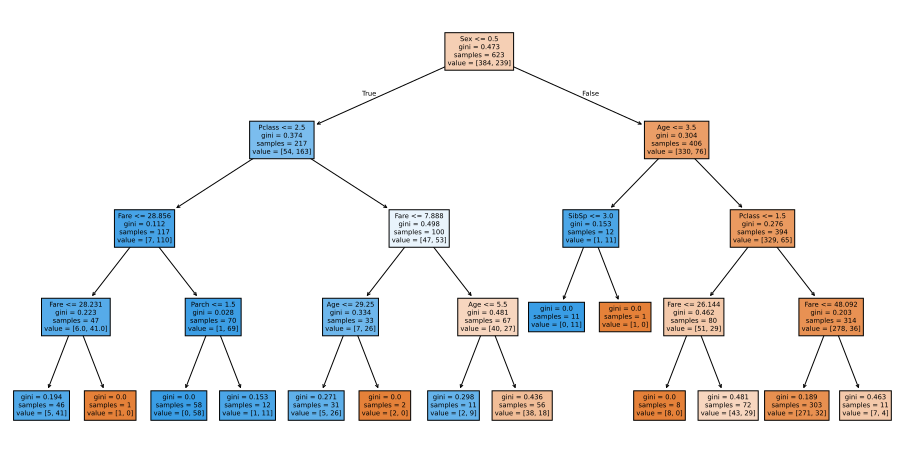

In [24]:
best_tree = DecisionTreeClassifier(max_depth=4,  random_state=RANDOM_STATE).fit(X_train,y_train)
plt.figure(figsize=(16, 8))
plot_tree(best_tree, feature_names=features, filled=True)
plt.show()

**5. Какой признак дерево считает самым важным? Постройте `feature_importances_` в виде bar plot. Совпадает ли это с тем, что вы видели на занятии 2 (countplot `Sex` с `hue='Survived'`)?**


<BarContainer object of 6 artists>

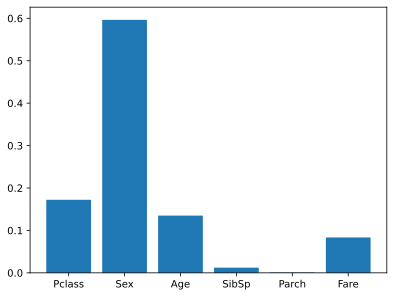

In [31]:
plt.bar(features, best_tree.feature_importances_)

**6. Обучите kNN (не забудьте масштабировать признаки через `StandardScaler`!) с `n_neighbors=10` и сравните accuracy на `X_valid` с лучшим деревом.**


In [43]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)

In [46]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_s,y_train)
knn.score(X_valid_s,y_valid), best_tree.score(X_valid,y_valid)


(0.7947761194029851, 0.7985074626865671)

**7 (бонус). Оцените лучшее дерево через `cross_val_score` с `cv=5` на всём `X`/`y` (не только на `X_train`). Устойчивы ли оценки по фолдам?**


In [49]:
res = cross_val_score(DecisionTreeClassifier(),X_train,y_train,cv=5,n_jobs=12)
res2 = cross_val_score(DecisionTreeClassifier(),X,y,cv=5,n_jobs=12)
print(max(res))
print(max(res2))


0.776
0.8258426966292135
